# Прогноз зарегистрированной цены жилого помещения в Казани

Цель — оценить зарегистрированную цену одиночного ДКП по площади, местоположению и характеристикам здания. Модель сравнивается с понятными рыночными baseline и проверяется на будущем квартале. Это исследовательская оценка, а не профессиональный отчёт об оценке недвижимости.

In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
INPUT_FILE = DATA_DIR / "kazan_residential_transactions_2025_clean.csv"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if not INPUT_FILE.exists():
    raise FileNotFoundError(
        "Сначала выполните ноутбук 03_data_cleaning.ipynb. "
        f"Ожидаемый файл: {INPUT_FILE}"
    )

data = pd.read_csv(INPUT_FILE, encoding="utf-8")
boolean_columns = [
    "is_single_property_contract",
    "is_multi_property_contract",
    "needs_price_review",
]
for column in boolean_columns:
    data[column] = data[column].replace({"True": True, "False": False})
    data[column] = data[column].fillna(False).astype(bool)

yellow = "#FFDD2D"
dark = "#333333"
gray = "#A0A0A0"
RANDOM_SEED = 42
data.head()

,property_count,okato,district,quarter_cad_number,street,realestate_type_code,wall_material_code,year_build,floor,purpose_code,area,period_start_date,deal_price,doc_type,quarter,floor_raw,is_single_property_contract,is_multi_property_contract,contract_segment,price_per_sqm,needs_price_review,has_complete_area_data,is_area_missing
0,1,92401380000,Приволжский,16:50:160205,Хусаина Мавлютова,2001003000,061001001001,1986.0,9.0,206002000000,56.90,2025-01-01,8900000.0,ДКП,Q1,9,True,False,один объект,156414.762742,False,True,False
1,3,92401367000,Вахитовский,16:50:011102,Старая,2001003000,NaN,NaN,NaN,206002000000,7991.31,2025-01-01,54923916.0,ДДУ,Q1,NaN,False,True,несколько объектов,NaN,False,True,False
2,1,92401367000,Вахитовский,16:50:011705,Николая Столбова,2001003000,061001003000,2020.0,2.0,206002000000,62.10,2025-01-01,26400000.0,ДКП,Q1,2,True,False,один объект,425120.772947,False,True,False
3,1,92401385000,Советский,16:50:060510,Комарова,2001003000,061001007001,1969.0,5.0,206002000000,59.40,2025-01-01,9000000.0,ДКП,Q1,5,True,False,один объект,151515.151515,False,True,False
4,1,92401363000,Авиастроительный,16:50:220526,Молодежная,2001003000,061001001001,1982.0,5.0,206002000000,12.90,2025-01-01,2200000.0,ДКП,Q1,5,True,False,один объект,170542.635659,False,True,False


## Область применения модели

Используются одиночные ДКП с положительной площадью и ценой. ДДУ исключены: в данных только 32 одиночных ДДУ, а характеристики строящихся объектов почти всегда отсутствуют. Ценовые флаги не удаляются из master-таблицы, но находятся вне основной области применения модели.

In [18]:
single_dkp = data.loc[
    (data["doc_type"] == "ДКП")
    & data["is_single_property_contract"]
].copy()

single_dkp["included_in_model"] = (
    ~single_dkp["needs_price_review"]
    & single_dkp["area"].notna()
    & (single_dkp["area"] > 0)
    & single_dkp["deal_price"].notna()
    & (single_dkp["deal_price"] > 0)
)
single_dkp["excluded_from_model"] = ~single_dkp["included_in_model"]

scope_summary = single_dkp.groupby("quarter").agg(
    одиночных_ДКП=("quarter", "size"),
    включено_в_модель=("included_in_model", "sum"),
    вне_области_модели=("excluded_from_model", "sum"),
)
scope_summary.loc["Всего"] = scope_summary.sum()
scope_summary

,одиночных_ДКП,включено_в_модель,вне_области_модели
quarter,,,
Q1,1359,1315,44
Q2,987,952,35
Q3,1206,1170,36
Q4,1438,1413,25
Всего,4990,4850,140


## Признаки и целевая переменная

Сравниваются базовый и детальный наборы признаков. Детальный вариант добавляет улицу и кадастровый квартал. Модель предсказывает логарифм цены квадратного метра, после чего оценка умножается на площадь и возвращается в рублях.

In [19]:
model_data = single_dkp.loc[single_dkp["included_in_model"]].copy()
model_data["building_age"] = 2025 - model_data["year_build"]
model_data["quarter_number"] = model_data["quarter"].map(
    {"Q1": 1, "Q2": 2, "Q3": 3, "Q4": 4}
)

numeric_features = [
    "area",
    "building_age",
    "floor",
    "quarter_number",
]
basic_categorical_features = [
    "district",
    "wall_material_code",
]
location_features = ["street", "quarter_cad_number"]
all_categorical_features = basic_categorical_features + location_features
basic_features = numeric_features + basic_categorical_features
detailed_features = basic_features + location_features

for column in all_categorical_features:
    model_data[column] = model_data[column].fillna("Неизвестно").astype(str)

forbidden_features = [
    "deal_price",
    "price_per_sqm",
    "needs_price_review",
    "property_count",
]
print(f"Наблюдений для моделирования: {len(model_data):,}")
print(f"Базовых признаков: {len(basic_features)}")
print(f"Детальных признаков: {len(detailed_features)}")
print(f"Исключены признаки с утечкой или константы: {forbidden_features}")

Наблюдений для моделирования: 4,850
Базовых признаков: 6
Детальных признаков: 8
Исключены признаки с утечкой или константы: ['deal_price', 'price_per_sqm', 'needs_price_review', 'property_count']


## Временное разбиение

Q1–Q2 используются для первичного обучения, Q3 — для выбора модели, а Q4 остаётся нетронутым финальным тестом. Такое разбиение сложнее случайного, но ближе к задаче оценки будущих зарегистрированных сделок.

In [20]:
train = model_data.loc[model_data["quarter"].isin(["Q1", "Q2"])].copy()
validation = model_data.loc[model_data["quarter"] == "Q3"].copy()
test = model_data.loc[model_data["quarter"] == "Q4"].copy()

split_summary = pd.DataFrame(
    {
        "часть": ["обучение", "валидация", "финальный тест"],
        "период": ["Q1–Q2", "Q3", "Q4"],
        "наблюдений": [len(train), len(validation), len(test)],
    }
)
split_summary

,часть,период,наблюдений
0,обучение,Q1–Q2,2267
1,валидация,Q3,1170
2,финальный тест,Q4,1413


## Метрики

Основная метрика — MAE в миллионах рублей: средняя абсолютная ошибка понятна в денежных единицах. Дополнительно рассчитываются медианная и средняя процентные ошибки, R² и доля прогнозов с отклонением не более 10% и 20%.

In [21]:
def calculate_metrics(model_name, actual, predicted):
    actual_values = np.asarray(actual, dtype=float)
    predicted_values = np.asarray(predicted, dtype=float)
    absolute_percentage_error = np.abs(
        (actual_values - predicted_values) / actual_values
    )

    return {
        "модель": model_name,
        "MAE, млн руб.": mean_absolute_error(
            actual_values, predicted_values
        ) / 1_000_000,
        "MdAPE, %": np.median(absolute_percentage_error) * 100,
        "MAPE, %": np.mean(absolute_percentage_error) * 100,
        "R²": r2_score(actual_values, predicted_values),
        "ошибка не более 10%, %": (absolute_percentage_error <= 0.10).mean() * 100,
        "ошибка не более 20%, %": (absolute_percentage_error <= 0.20).mean() * 100,
    }

## Рыночные baseline

Модель должна превосходить не только общую медиану, но и практичные правила: городская медиана за м², умноженная на площадь, и медиана района за м² с городской медианой для неизвестного района. Все медианы рассчитываются только на обучающей части.

In [22]:
validation_metric_rows = []
validation_predictions = {}
validation_actual = validation["deal_price"]

global_median_price = train["deal_price"].median()
global_median_prediction = np.repeat(
    global_median_price, len(validation)
)
validation_predictions["Общая медиана цены"] = global_median_prediction
validation_metric_rows.append(
    calculate_metrics(
        "Общая медиана цены",
        validation_actual,
        global_median_prediction,
    )
)

global_median_ppsm = train["price_per_sqm"].median()
global_ppsm_prediction = validation["area"] * global_median_ppsm
validation_predictions["Медиана Казани за м² × площадь"] = global_ppsm_prediction
validation_metric_rows.append(
    calculate_metrics(
        "Медиана Казани за м² × площадь",
        validation_actual,
        global_ppsm_prediction,
    )
)

district_median_ppsm = train.groupby("district")["price_per_sqm"].median()
validation_district_ppsm = validation["district"].map(district_median_ppsm)
validation_district_ppsm = validation_district_ppsm.fillna(global_median_ppsm)
district_ppsm_prediction = validation["area"] * validation_district_ppsm
validation_predictions["Медиана района за м² × площадь"] = district_ppsm_prediction
validation_metric_rows.append(
    calculate_metrics(
        "Медиана района за м² × площадь",
        validation_actual,
        district_ppsm_prediction,
    )
)

pd.DataFrame(validation_metric_rows)

,модель,"MAE, млн руб.","MdAPE, %","MAPE, %",R²,"ошибка не более 10%, %","ошибка не более 20%, %"
0,Общая медиана цены,3.066624,30.000000,51.866586,-0.045503,17.863248,36.068376
1,Медиана Казани за м² × площадь,2.100677,20.877943,30.984542,0.498677,23.076923,47.179487
2,Медиана района за м² × площадь,2.033514,20.373827,30.134548,0.509223,27.094017,49.658120


## Линейная модель

Ridge-регрессия служит интерпретируемой ML-точкой сравнения. Числовые пропуски заполняются медианой обучающей части, категории кодируются one-hot, а модель предсказывает логарифм полной цены.

In [23]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("one_hot", OneHotEncoder(handle_unknown="ignore")),
    ]
)
linear_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, basic_categorical_features),
    ]
)
ridge_model = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        ("model", Ridge(alpha=1.0)),
    ]
)
ridge_model.fit(
    train[basic_features],
    np.log(train["deal_price"]),
)
ridge_validation_prediction = np.exp(
    ridge_model.predict(validation[basic_features])
)
validation_predictions["Ridge: log цены"] = ridge_validation_prediction
validation_metric_rows.append(
    calculate_metrics(
        "Ridge: log цены",
        validation_actual,
        ridge_validation_prediction,
    )
)
pd.DataFrame(validation_metric_rows).tail(1)

,модель,"MAE, млн руб.","MdAPE, %","MAPE, %",R²,"ошибка не более 10%, %","ошибка не более 20%, %"
3,Ridge: log цены,1.981111,18.328014,30.160291,-0.718847,27.863248,54.102564


## Нелинейные модели CatBoost

Проверяются два набора признаков и две постановки цели: логарифм полной цены и логарифм цены за м². Early stopping выбирает число итераций по Q3 и ограничивает переобучение.

In [24]:
catboost_configurations = [
    {
        "name": "CatBoost: базовые, log цены",
        "features": basic_features,
        "categories": basic_categorical_features,
        "target": "price",
    },
    {
        "name": "CatBoost: детальные, log цены",
        "features": detailed_features,
        "categories": all_categorical_features,
        "target": "price",
    },
    {
        "name": "CatBoost: базовые, log цены за м²",
        "features": basic_features,
        "categories": basic_categorical_features,
        "target": "ppsm",
    },
    {
        "name": "CatBoost: детальные, log цены за м²",
        "features": detailed_features,
        "categories": all_categorical_features,
        "target": "ppsm",
    },
]

catboost_models = {}
for configuration in catboost_configurations:
    model_name = configuration["name"]
    model_features = configuration["features"]
    categorical_features = configuration["categories"]
    target_type = configuration["target"]

    if target_type == "price":
        train_target = np.log(train["deal_price"])
        validation_target = np.log(validation["deal_price"])
    else:
        train_target = np.log(train["price_per_sqm"])
        validation_target = np.log(validation["price_per_sqm"])

    candidate_model = CatBoostRegressor(
        iterations=1_000,
        depth=6,
        learning_rate=0.03,
        loss_function="RMSE",
        random_seed=RANDOM_SEED,
        verbose=False,
        allow_writing_files=False,
    )
    candidate_model.fit(
        train[model_features],
        train_target,
        cat_features=categorical_features,
        eval_set=(validation[model_features], validation_target),
        early_stopping_rounds=75,
        verbose=False,
    )

    transformed_prediction = np.exp(
        candidate_model.predict(validation[model_features])
    )
    if target_type == "ppsm":
        candidate_prediction = transformed_prediction * validation["area"]
    else:
        candidate_prediction = transformed_prediction

    catboost_models[model_name] = candidate_model
    validation_predictions[model_name] = candidate_prediction
    validation_metric_rows.append(
        calculate_metrics(
            model_name,
            validation_actual,
            candidate_prediction,
        )
    )

print(f"Обучено моделей CatBoost: {len(catboost_models)}")

Обучено моделей CatBoost: 4


## Выбор модели на Q3

Конфигурация выбирается только по валидационному MAE. Q4 до этого момента не используется ни для выбора алгоритма, ни для настройки параметров.

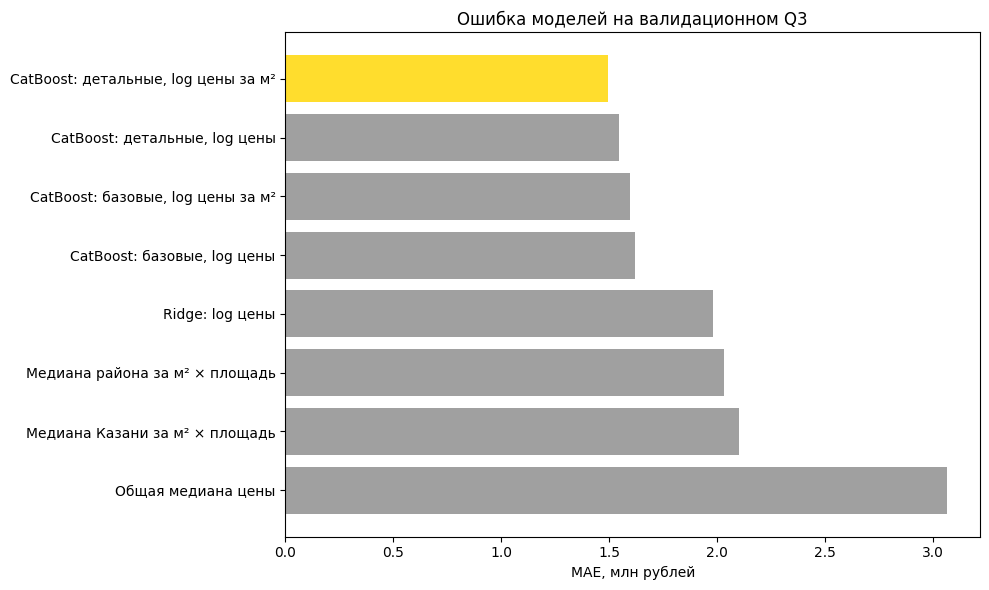

Выбрана модель: CatBoost: детальные, log цены за м²
Итераций после early stopping: 504
Улучшение MAE относительно районного baseline: 26.4%


,модель,"MAE, млн руб.","MdAPE, %","MAPE, %",R²,"ошибка не более 10%, %","ошибка не более 20%, %"
0,"CatBoost: детальные, log цены за м²",1.50,13.69,23.10,0.72,36.84,67.69
1,"CatBoost: детальные, log цены",1.54,13.71,23.61,0.68,36.15,65.21
2,"CatBoost: базовые, log цены за м²",1.60,15.35,24.10,0.70,33.85,62.82
3,"CatBoost: базовые, log цены",1.62,15.49,24.36,0.67,32.22,62.14
4,Ridge: log цены,1.98,18.33,30.16,-0.72,27.86,54.10
5,Медиана района за м² × площадь,2.03,20.37,30.13,0.51,27.09,49.66
6,Медиана Казани за м² × площадь,2.10,20.88,30.98,0.50,23.08,47.18
7,Общая медиана цены,3.07,30.00,51.87,-0.05,17.86,36.07


In [25]:
validation_results = pd.DataFrame(validation_metric_rows)
validation_results = validation_results.sort_values("MAE, млн руб.")
validation_results = validation_results.reset_index(drop=True)

selected_model_name = "CatBoost: детальные, log цены за м²"
if validation_results.iloc[0]["модель"] != selected_model_name:
    raise ValueError("Лучшая конфигурация изменилась — проверьте выбор финальной модели.")
selected_validation_model = catboost_models[selected_model_name]
selected_validation_prediction = validation_predictions[selected_model_name]
selected_iterations = selected_validation_model.get_best_iteration() + 1

district_baseline_mae = validation_results.loc[
    validation_results["модель"] == "Медиана района за м² × площадь",
    "MAE, млн руб.",
].iloc[0]
selected_validation_mae = validation_results.loc[
    validation_results["модель"] == selected_model_name,
    "MAE, млн руб.",
].iloc[0]
validation_improvement = (
    (district_baseline_mae - selected_validation_mae)
    / district_baseline_mae
    * 100
)

validation_plot = validation_results.sort_values("MAE, млн руб.", ascending=False)
bar_colors = [
    yellow if name == selected_model_name else gray
    for name in validation_plot["модель"]
]
fig, axis = plt.subplots(figsize=(10, 6))
axis.barh(
    validation_plot["модель"],
    validation_plot["MAE, млн руб."],
    color=bar_colors,
)
axis.set_title("Ошибка моделей на валидационном Q3")
axis.set_xlabel("MAE, млн рублей")
axis.set_ylabel("")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "09_model_validation.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Выбрана модель: {selected_model_name}")
print(f"Итераций после early stopping: {selected_iterations}")
print(f"Улучшение MAE относительно районного baseline: {validation_improvement:.1f}%")
validation_results.round(2)

## Финальное обучение и тест на Q4

Выбранная модель переобучается на Q1–Q3 с числом итераций, определённым на Q3. После этого один раз рассчитываются метрики на нетронутом Q4. Baseline также пересчитываются только по Q1–Q3.

In [26]:
development = model_data.loc[
    model_data["quarter"].isin(["Q1", "Q2", "Q3"])
].copy()

final_model = CatBoostRegressor(
    iterations=selected_iterations,
    depth=6,
    learning_rate=0.03,
    loss_function="RMSE",
    random_seed=RANDOM_SEED,
    verbose=False,
    allow_writing_files=False,
)
final_model.fit(
    development[detailed_features],
    np.log(development["price_per_sqm"]),
    cat_features=all_categorical_features,
    verbose=False,
)

predicted_test_ppsm = np.exp(
    final_model.predict(test[detailed_features])
)
predicted_test_price = predicted_test_ppsm * test["area"]

development_global_ppsm = development["price_per_sqm"].median()
test_global_ppsm_prediction = test["area"] * development_global_ppsm
development_district_ppsm = development.groupby("district")["price_per_sqm"].median()
test_district_ppsm = test["district"].map(development_district_ppsm)
test_district_ppsm = test_district_ppsm.fillna(development_global_ppsm)
test_district_prediction = test["area"] * test_district_ppsm

test_metric_rows = [
    calculate_metrics(
        "Медиана Казани за м² × площадь",
        test["deal_price"],
        test_global_ppsm_prediction,
    ),
    calculate_metrics(
        "Медиана района за м² × площадь",
        test["deal_price"],
        test_district_prediction,
    ),
    calculate_metrics(
        "Выбранный CatBoost",
        test["deal_price"],
        predicted_test_price,
    ),
]
test_results = pd.DataFrame(test_metric_rows)
test_results = test_results.sort_values("MAE, млн руб.").reset_index(drop=True)
test_results.round(2)

,модель,"MAE, млн руб.","MdAPE, %","MAPE, %",R²,"ошибка не более 10%, %","ошибка не более 20%, %"
0,Выбранный CatBoost,1.35,13.64,21.02,0.74,37.01,69.07
1,Медиана района за м² × площадь,1.86,19.15,27.84,0.50,28.52,52.37
2,Медиана Казани за м² × площадь,1.94,19.94,28.99,0.47,26.75,50.18


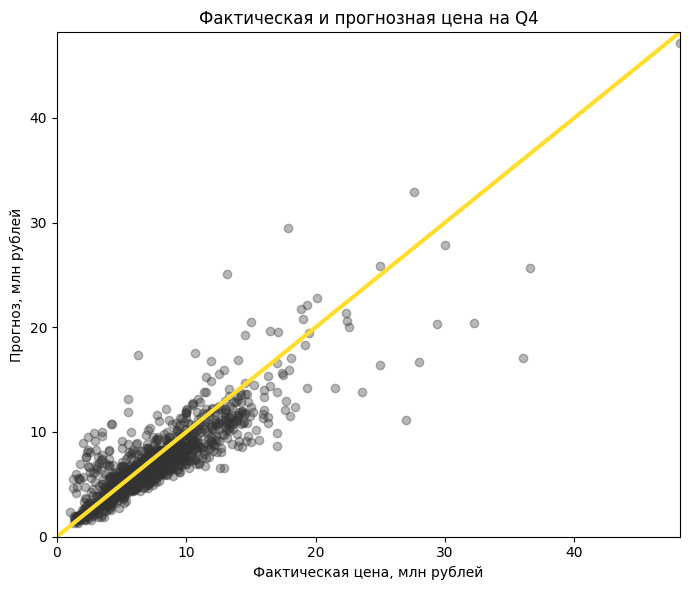

Улучшение MAE относительно районного baseline на Q4: 27.3%


In [27]:
selected_test_mae = test_results.loc[
    test_results["модель"] == "Выбранный CatBoost",
    "MAE, млн руб.",
].iloc[0]
test_district_baseline_mae = test_results.loc[
    test_results["модель"] == "Медиана района за м² × площадь",
    "MAE, млн руб.",
].iloc[0]
test_improvement = (
    (test_district_baseline_mae - selected_test_mae)
    / test_district_baseline_mae
    * 100
)

actual_test_mln = test["deal_price"] / 1_000_000
predicted_test_mln = predicted_test_price / 1_000_000
plot_limit = max(actual_test_mln.max(), predicted_test_mln.max())

fig, axis = plt.subplots(figsize=(7, 6))
axis.scatter(
    actual_test_mln,
    predicted_test_mln,
    alpha=0.35,
    color=dark,
)
axis.plot([0, plot_limit], [0, plot_limit], color=yellow, linewidth=3)
axis.set_xlim(0, plot_limit)
axis.set_ylim(0, plot_limit)
axis.set_title("Фактическая и прогнозная цена на Q4")
axis.set_xlabel("Фактическая цена, млн рублей")
axis.set_ylabel("Прогноз, млн рублей")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "10_model_test.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Улучшение MAE относительно районного baseline на Q4: {test_improvement:.1f}%")

## Где модель ошибается

Ошибка рассматривается по ценовым сегментам, районам и новизне географических категорий. Ценовой сегмент используется только после прогнозирования и не является признаком модели.

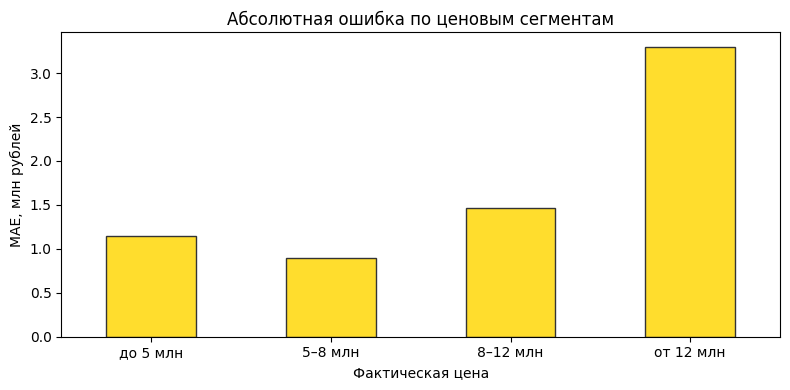

,наблюдений,MdAPE,"MAE, млн руб."
price_group,,,
до 5 млн,320,17.50,1.15
5–8 млн,591,11.24,0.89
8–12 млн,347,14.92,1.47
от 12 млн,155,18.32,3.30


,наблюдений,MdAPE,"MAE, млн руб."
district_for_analysis,,,
Авиастроительный,103,12.11,0.84
Кировский,146,13.81,1.18
Приволжский,244,12.58,1.28
Советский,366,11.45,1.28
Московский,64,17.12,1.32
Неизвестно,257,14.16,1.38
Ново-Савиновский,164,18.14,1.83
Вахитовский,69,15.76,1.98


,наблюдений,MdAPE,"MAE, млн руб."
street_status,,,
новая улица,41,18.07,2.07
улица встречалась ранее,1372,13.43,1.33


,наблюдений,MdAPE,"MAE, млн руб."
cadastre_status,,,
квартал встречался ранее,1368,13.36,1.31
новый кадастровый квартал,45,23.55,2.66


In [28]:
test_predictions = test.copy()
test_predictions["predicted_price"] = np.asarray(predicted_test_price)
test_predictions["absolute_error"] = np.abs(
    test_predictions["deal_price"] - test_predictions["predicted_price"]
)
test_predictions["absolute_percentage_error"] = (
    test_predictions["absolute_error"] / test_predictions["deal_price"] * 100
)

test_predictions["price_group"] = pd.NA
test_predictions.loc[test_predictions["deal_price"] < 5_000_000, "price_group"] = "до 5 млн"
test_predictions.loc[
    (test_predictions["deal_price"] >= 5_000_000)
    & (test_predictions["deal_price"] < 8_000_000),
    "price_group",
] = "5–8 млн"
test_predictions.loc[
    (test_predictions["deal_price"] >= 8_000_000)
    & (test_predictions["deal_price"] < 12_000_000),
    "price_group",
] = "8–12 млн"
test_predictions.loc[test_predictions["deal_price"] >= 12_000_000, "price_group"] = "от 12 млн"
price_group_order = ["до 5 млн", "5–8 млн", "8–12 млн", "от 12 млн"]

error_by_price = test_predictions.groupby("price_group").agg(
    наблюдений=("price_group", "size"),
    MAE=("absolute_error", "mean"),
    MdAPE=("absolute_percentage_error", "median"),
).reindex(price_group_order)
error_by_price["MAE, млн руб."] = error_by_price["MAE"] / 1_000_000

test_predictions["district_for_analysis"] = test_predictions["district"].fillna("Неизвестно")
error_by_district = test_predictions.groupby("district_for_analysis").agg(
    наблюдений=("district_for_analysis", "size"),
    MAE=("absolute_error", "mean"),
    MdAPE=("absolute_percentage_error", "median"),
)
error_by_district["MAE, млн руб."] = error_by_district["MAE"] / 1_000_000
error_by_district = error_by_district.sort_values("MAE, млн руб.")

seen_streets = set(development["street"])
seen_cadastral_quarters = set(development["quarter_cad_number"])
test_predictions["street_status"] = np.where(
    test_predictions["street"].isin(seen_streets),
    "улица встречалась ранее",
    "новая улица",
)
test_predictions["cadastre_status"] = np.where(
    test_predictions["quarter_cad_number"].isin(seen_cadastral_quarters),
    "квартал встречался ранее",
    "новый кадастровый квартал",
)
location_error = test_predictions.groupby("street_status").agg(
    наблюдений=("street_status", "size"),
    MAE=("absolute_error", "mean"),
    MdAPE=("absolute_percentage_error", "median"),
)
location_error["MAE, млн руб."] = location_error["MAE"] / 1_000_000
cadastre_error = test_predictions.groupby("cadastre_status").agg(
    наблюдений=("cadastre_status", "size"),
    MAE=("absolute_error", "mean"),
    MdAPE=("absolute_percentage_error", "median"),
)
cadastre_error["MAE, млн руб."] = cadastre_error["MAE"] / 1_000_000

fig, axis = plt.subplots(figsize=(8, 4))
error_by_price["MAE, млн руб."].plot(
    kind="bar", ax=axis, color=yellow, edgecolor=dark
)
axis.set_title("Абсолютная ошибка по ценовым сегментам")
axis.set_xlabel("Фактическая цена")
axis.set_ylabel("MAE, млн рублей")
axis.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "11_model_error_segments.png", dpi=150, bbox_inches="tight")
plt.show()

display(error_by_price.drop(columns="MAE").round(2))
display(error_by_district.drop(columns="MAE").round(2))
display(location_error.drop(columns="MAE").round(2))
cadastre_error.drop(columns="MAE").round(2)

## Интервал неопределённости

Остатки Q3 используются для построения единого эмпирического 80%-интервала. Его покрытие затем измеряется на Q4. Интервал отражает общую ошибку модели, но не учитывает индивидуальную неопределённость конкретного объекта.

In [29]:
validation_log_residual = np.log(
    validation["deal_price"] / selected_validation_prediction
)
lower_multiplier = np.exp(validation_log_residual.quantile(0.10))
upper_multiplier = np.exp(validation_log_residual.quantile(0.90))

test_predictions["lower_price"] = (
    test_predictions["predicted_price"] * lower_multiplier
)
test_predictions["upper_price"] = (
    test_predictions["predicted_price"] * upper_multiplier
)
test_predictions["inside_interval"] = (
    (test_predictions["deal_price"] >= test_predictions["lower_price"])
    & (test_predictions["deal_price"] <= test_predictions["upper_price"])
)
interval_coverage = test_predictions["inside_interval"].mean() * 100
median_interval_width = (
    test_predictions["upper_price"] - test_predictions["lower_price"]
).median() / 1_000_000

sorted_test_predictions = test_predictions.sort_values("deal_price")
example_positions = np.linspace(
    0, len(sorted_test_predictions) - 1, 7, dtype=int
)
prediction_examples = sorted_test_predictions.iloc[example_positions][
    [
        "district",
        "street",
        "area",
        "year_build",
        "floor",
        "deal_price",
        "predicted_price",
        "lower_price",
        "upper_price",
    ]
]

print(f"Множители интервала: {lower_multiplier:.3f} — {upper_multiplier:.3f}")
print(f"Покрытие на Q4: {interval_coverage:.1f}%")
print(f"Медианная ширина интервала: {median_interval_width:.2f} млн рублей")
prediction_examples.round(0)

Множители интервала: 0.759 — 1.349
Покрытие на Q4: 83.7%
Медианная ширина интервала: 3.82 млн рублей


,district,street,area,year_build,floor,deal_price,predicted_price,lower_price,upper_price
4293,Советский,Солидарности (Дербышки),17.0,1979.0,2.0,1015000.0,2389878.0,1813093.0,3223651.0
5381,Советский,Солидарности (Дербышки),34.0,1975.0,3.0,4200000.0,4794734.0,3637549.0,6467506.0
4940,Ново-Савиновский,Мусина,50.0,1985.0,2.0,5800000.0,6275609.0,4761023.0,8465024.0
5393,Кировский,Залесная,51.0,1983.0,2.0,6900000.0,5523312.0,4190289.0,7450269.0
4195,Неизвестно,Батыршина,50.0,1977.0,8.0,8150000.0,6796996.0,5156576.0,9168312.0
5155,Советский,Волочаевская,60.0,2011.0,10.0,10390000.0,9475371.0,7188538.0,12781110.0
4182,Вахитовский,Айвазовского,173.0,2025.0,2.0,48168000.0,47196628.0,35805963.0,63662446.0


## Какие признаки помогают модели

Permutation importance измеряется на Q3: значения одного признака перемешиваются, после чего оценивается ухудшение MAE логарифма цены за м². Метод показывает вклад в прогноз, но не причинное влияние на цену.

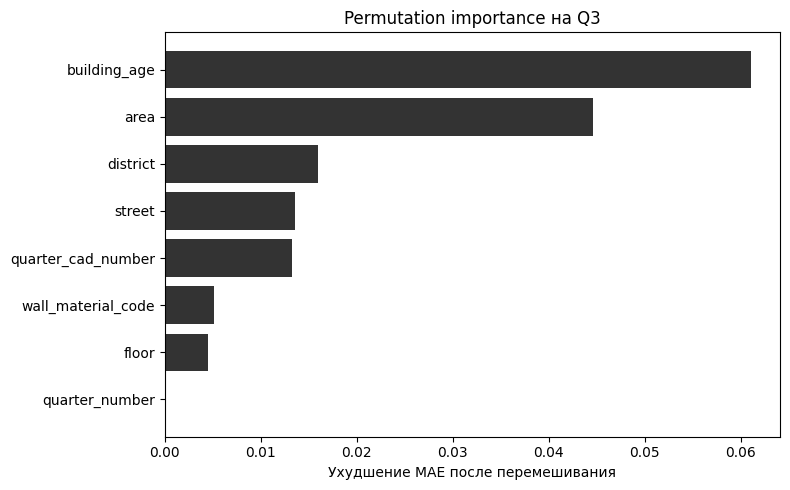

,признак,среднее_ухудшение_MAE,стандартное_отклонение
1,building_age,0.0610,0.0030
0,area,0.0446,0.0015
4,district,0.0160,0.0011
6,street,0.0136,0.0010
7,quarter_cad_number,0.0133,0.0013
5,wall_material_code,0.0051,0.0008
2,floor,0.0045,0.0013
3,quarter_number,0.0000,0.0000


In [30]:
importance_result = permutation_importance(
    selected_validation_model,
    validation[detailed_features],
    np.log(validation["price_per_sqm"]),
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=RANDOM_SEED,
)
importance_summary = pd.DataFrame(
    {
        "признак": detailed_features,
        "среднее_ухудшение_MAE": importance_result.importances_mean,
        "стандартное_отклонение": importance_result.importances_std,
    }
)
importance_summary = importance_summary.sort_values(
    "среднее_ухудшение_MAE", ascending=True
)

fig, axis = plt.subplots(figsize=(8, 5))
axis.barh(
    importance_summary["признак"],
    importance_summary["среднее_ухудшение_MAE"],
    color=dark,
)
axis.set_title("Permutation importance на Q3")
axis.set_xlabel("Ухудшение MAE после перемешивания")
axis.set_ylabel("")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "12_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

importance_summary.sort_values("среднее_ухудшение_MAE", ascending=False).round(4)

## Проверка за пределами основной области

Основные метрики относятся к Q4 без ценовых флагов. Ниже модель дополнительно проверяется на всех одиночных ДКП Q4, включая необычные сделки. Этот результат показывает устойчивость, но не меняет заранее определённую область применения.

In [31]:
all_q4 = single_dkp.loc[
    (single_dkp["quarter"] == "Q4")
    & single_dkp["area"].notna()
    & (single_dkp["area"] > 0)
    & single_dkp["deal_price"].notna()
    & (single_dkp["deal_price"] > 0)
].copy()
all_q4["building_age"] = 2025 - all_q4["year_build"]
all_q4["quarter_number"] = 4
for column in all_categorical_features:
    all_q4[column] = all_q4[column].fillna("Неизвестно").astype(str)

all_q4_predicted_ppsm = np.exp(
    final_model.predict(all_q4[detailed_features])
)
all_q4_predicted_price = all_q4_predicted_ppsm * all_q4["area"]

scope_test_results = pd.DataFrame(
    [
        calculate_metrics(
            "Основная выборка Q4",
            test["deal_price"],
            predicted_test_price,
        ),
        calculate_metrics(
            "Все одиночные ДКП Q4",
            all_q4["deal_price"],
            all_q4_predicted_price,
        ),
    ]
)
scope_test_results.round(2)

,модель,"MAE, млн руб.","MdAPE, %","MAPE, %",R²,"ошибка не более 10%, %","ошибка не более 20%, %"
0,Основная выборка Q4,1.35,13.64,21.02,0.74,37.01,69.07
1,Все одиночные ДКП Q4,1.48,13.95,35.05,0.67,36.51,68.08


## Пример использования

Функция возвращает оценку зарегистрированной цены и общий 80%-интервал. Неизвестные категории допустимы, однако прогноз обычно надёжнее для местоположений, представленных в обучающих данных.

In [32]:
def estimate_registered_price(
    area,
    year_build=None,
    floor=None,
    district="Неизвестно",
    wall_material_code="Неизвестно",
    street="Неизвестно",
    quarter_cad_number="Неизвестно",
):
    building_age = np.nan
    if year_build is not None:
        building_age = 2025 - year_build

    floor_value = np.nan if floor is None else floor
    example = pd.DataFrame(
        {
            "area": [area],
            "building_age": [building_age],
            "floor": [floor_value],
            "quarter_number": [4],
            "district": [str(district)],
            "wall_material_code": [str(wall_material_code)],
            "street": [str(street)],
            "quarter_cad_number": [str(quarter_cad_number)],
        }
    )

    estimated_ppsm = np.exp(
        final_model.predict(example[detailed_features])[0]
    )
    estimated_price = estimated_ppsm * area

    return pd.DataFrame(
        {
            "оценка_цены": [estimated_price],
            "оценка_цены_за_м²": [estimated_ppsm],
            "нижняя_граница": [estimated_price * lower_multiplier],
            "верхняя_граница": [estimated_price * upper_multiplier],
        }
    )


example_estimate = estimate_registered_price(
    area=50,
    year_build=2015,
    floor=7,
    district="Советский",
)
example_estimate.round(0)

,оценка_цены,оценка_цены_за_м²,нижняя_граница,верхняя_граница
0,8422555.0,168451.0,6389814.0,11360991.0


## Основной результат

На валидационном Q3 CatBoost с детальной географией и прогнозом цены за м² снижает MAE относительно районного baseline примерно на 26%. На нетронутом Q4 модель достигает MAE 1,35 млн рублей, MdAPE 13,6% и R² 0,74; 69,1% прогнозов отличаются от зарегистрированной цены не более чем на 20%. Улучшение относительно районного baseline на Q4 составляет 27%.

Эмпирический 80%-интервал покрывает 83,7% тестовых наблюдений. Следовательно, детальная география и характеристики здания дают полезный прирост качества сверх простого правила «медиана района за м² × площадь».

## Ограничения

- Модель обучена только на типичных одиночных ДКП 2025 года и не предназначена для ДДУ или пакетных договоров.
- В данных нет числа комнат, состояния ремонта, точного дома и координат — важных факторов стоимости.
- Район неизвестен для части наблюдений, а некоторые улицы и кадастровые кварталы впервые появляются в Q4.
- Интервал неопределённости общий для всех объектов и не является формальным индивидуальным доверительным интервалом.
- Модель оценивает зарегистрированную цену в рамках изученной выборки, а не рыночную стоимость по стандартам профессиональной оценки.